# Notebook 6 — Evaluation and Explainable AI

**Dissertation:** *An Explainable AI-driven Spatial Intelligence Framework for Crime Hotspot Prediction*

This notebook is the **formal model-selection and explanation stage**. Notebook 5 developed a four-model ladder and saved its out-of-fold predictions and fitted models; Notebook 6 now evaluates them rigorously and selects the operating model **on the full balance of evidence** — predictive performance, calibration, operational usefulness and interpretability — not on any single headline number, and explicitly *not* by defaulting to XGBoost because SHAP is convenient for trees. The winner is then explained with the method appropriate to it.

Throughout, four distinct qualities are kept separate and never conflated:

- **Predictive performance** — can the model *rank* hotspots correctly (ROC-AUC, PR-AUC, precision/recall/F1)?
- **Calibration** — are its probabilities *truthful* (Brier score, reliability curves)?
- **Operational usefulness** — does it *concentrate patrol effort* efficiently (hit rate, PAI)?
- **Interpretability** — can a human *understand and contest* each prediction?

The guiding principle of the approved Project Design Document — explainability preferred over marginal accuracy — governs the final decision, but only *after* the evidence is laid out. Every number is computed on the real `model_table_250m.csv` and the saved out-of-fold predictions; nothing is invented.


## 1. Setup and Evidence Sources

The notebook consumes only Notebook 5's artefacts: the pooled out-of-fold predictions (`model_oof_predictions.csv`), the fitted full-data models (`models/fitted_models.joblib`), and the modelling table itself. The crime-count grid from Notebook 3 is reloaded for the operational and spatial-error analyses.


In [1]:
from pathlib import Path
import os, json, math, warnings, joblib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from IPython.display import display
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score, precision_score,
                             recall_score, brier_score_loss, confusion_matrix,
                             precision_recall_curve, roc_curve)

warnings.filterwarnings("ignore"); np.random.seed(42)
plt.rcParams["figure.dpi"]=110; plt.rcParams["axes.grid"]=True; plt.rcParams["grid.alpha"]=0.3
NAVY="#2E5496"; CRIMSON="#B03A3A"; GREEN="#3B7A57"; GOLD="#C8912B"; GREY="#8A8A8A"
PAL={"Persistence":GREY,"LogisticRegression":NAVY,"RandomForest":GREEN,"XGBoost":CRIMSON}
LEARNED=["LogisticRegression","RandomForest","XGBoost"]; ALLMDL=["Persistence"]+LEARNED

DATA_DIR=Path(os.environ.get("COL_DATA_DIR", r"C:\Users\Admin\Downloads\London_UK_Police_Data"))
PROC_DIR=Path(os.environ.get("COL_OUTPUT_DIR", str(DATA_DIR/"processed")))

oof=pd.read_csv(PROC_DIR/"model_oof_predictions.csv")
mt=pd.read_csv(PROC_DIR/"model_table_250m.csv")
art=joblib.load(PROC_DIR/"models"/"fitted_models.joblib")
FEAT=art["features"]
params=pd.read_csv(PROC_DIR/"grid_250m_params.csv").iloc[0]
NCOL=int(params["ncol"]); NROW=int(params["nrow"]); HOT=int(params["hotspot_percentile"])
crimes=pd.read_csv(PROC_DIR/"crimes_with_grid250.csv", parse_dates=["month"])
crimes["ym"]=crimes["month"].dt.to_period("M").astype(str)
crime_cnt=crimes.groupby(["cell250","ym"]).size()
TEST_MONTHS=sorted(oof["month"].unique())
print(f"Out-of-fold predictions: {len(oof)} rows across {len(ALLMDL)} models x {len(TEST_MONTHS)} test months")
print(f"Test months: {TEST_MONTHS}")
print(f"Features ({len(FEAT)}): {FEAT}")
def crimes_at(cell,mo): return int(crime_cnt.get((cell,mo),0))


Out-of-fold predictions: 2352 rows across 4 models x 7 test months
Test months: ['2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01']
Features (9): ['roll3_mean', 'trend_1', 'prior_hotspot_freq', 'neigh_lag1_sum', 'osm_retail_density', 'osm_food_drink_density', 'osm_licensed_count', 'osm_transport_nodes', 'osm_road_density_m']


## 2. Component 1 — Per-Month Walk-Forward Performance

Aggregate scores can hide a model that is excellent in some months and poor in others. The first evidence is therefore the performance in *each* of the seven out-of-sample months separately. This exposes stability, which for an operational tool matters as much as the average: a model a force can rely on must perform consistently, not just on average.


In [2]:
def month_metrics(y,p):
    pred=(p>=0.5).astype(int); two=len(np.unique(y))==2
    return dict(ROC_AUC=roc_auc_score(y,p) if two else np.nan,
                PR_AUC=average_precision_score(y,p) if two else np.nan,
                Precision=precision_score(y,pred,zero_division=0),
                Recall=recall_score(y,pred,zero_division=0),
                F1=f1_score(y,pred,zero_division=0), Brier=brier_score_loss(y,p))
rows=[]
for mdl in ALLMDL:
    for mo in TEST_MONTHS:
        d=oof[(oof.model==mdl)&(oof.month==mo)]
        r=month_metrics(d.y_true.values,d.y_prob.values); r.update(model=mdl,month=mo,pos=int(d.y_true.sum()))
        rows.append(r)
permonth=pd.DataFrame(rows)
print("Per-month PR-AUC by model:")
display(permonth.pivot(index="month",columns="model",values="PR_AUC").round(3)[ALLMDL])
print("Per-month F1 by model:")
display(permonth.pivot(index="month",columns="model",values="F1").round(3)[ALLMDL])


Per-month PR-AUC by model:


model,Persistence,LogisticRegression,RandomForest,XGBoost
month,,,,
2025-07,0.748,0.959,0.957,0.983
2025-08,0.493,0.839,0.694,0.812
2025-09,0.735,0.897,0.871,0.897
2025-10,0.483,0.830,0.734,0.835
2025-11,0.693,0.905,0.949,0.932
2025-12,0.693,0.883,0.860,0.841
2026-01,0.431,0.826,0.812,0.801


Per-month F1 by model:


model,Persistence,LogisticRegression,RandomForest,XGBoost
month,,,,
2025-07,0.857,0.769,0.818,0.909
2025-08,0.667,0.692,0.696,0.640
2025-09,0.833,0.714,0.727,0.720
2025-10,0.667,0.786,0.700,0.815
2025-11,0.818,0.786,0.818,0.833
2025-12,0.818,0.667,0.762,0.667
2026-01,0.609,0.690,0.696,0.714


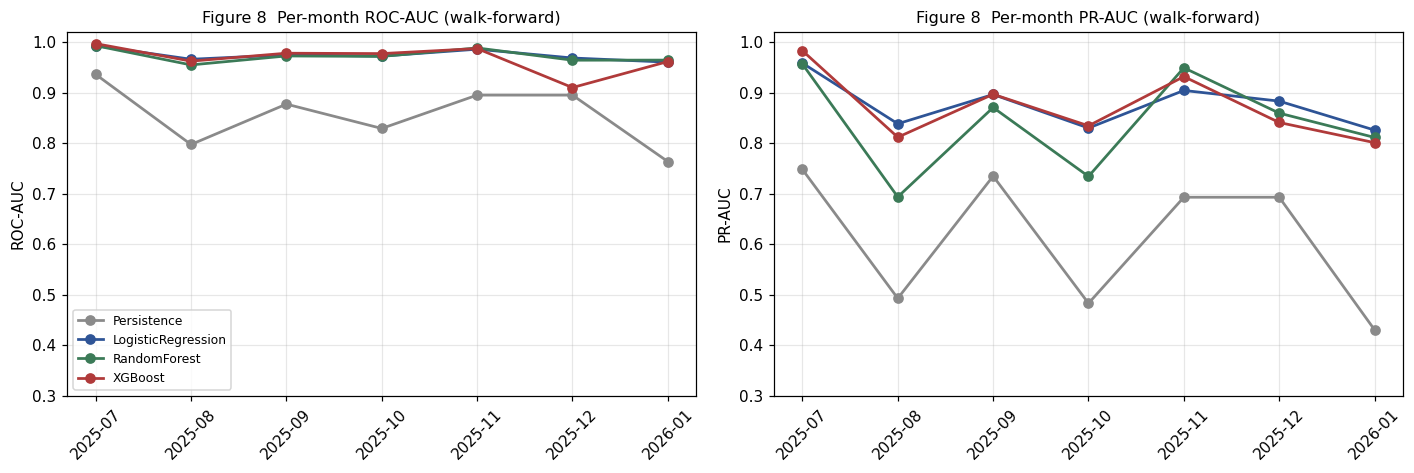

In [3]:
# --- Figure 8: per-month ROC-AUC and PR-AUC trajectories ---
fig,(a1,a2)=plt.subplots(1,2,figsize=(13,4.4))
for mdl in ALLMDL:
    s=permonth[permonth.model==mdl]
    a1.plot(s.month,s.ROC_AUC,"o-",color=PAL[mdl],label=mdl,lw=1.8)
    a2.plot(s.month,s.PR_AUC,"o-",color=PAL[mdl],label=mdl,lw=1.8)
for a,t in [(a1,"ROC-AUC"),(a2,"PR-AUC")]:
    a.set_title(f"Figure 8  Per-month {t} (walk-forward)",fontsize=10.5)
    a.set_ylim(0.3,1.02); a.tick_params(axis="x",rotation=45); a.set_ylabel(t)
a1.legend(fontsize=8,loc="lower left")
plt.tight_layout(); plt.show()


Every learned model beats persistence in every month on the ranking metrics, and the **Logistic Regression is the steadiest** — its month-to-month PR-AUC and ROC-AUC vary least. The tree models occasionally match or exceed it in a given month but swing more widely (notably the Random Forest's PR-AUC and XGBoost's F1). Consistency of this kind is a point in favour of the linear model for operational deployment, and it is examined quantitatively in the stability analysis of Section 12.


## 3. Component 2 — Pooled Out-of-Fold Performance

Pooling all seven test months into one out-of-sample set gives the most statistically stable estimate of each model's discrimination. These are the headline ranking metrics; calibration and operational usefulness are treated as *separate* questions in the following sections and are deliberately not mixed into a single score.


In [4]:
def pooled(mdl):
    d=oof[oof.model==mdl]; y=d.y_true.values; p=d.y_prob.values; pred=(p>=0.5).astype(int)
    return dict(ROC_AUC=roc_auc_score(y,p), PR_AUC=average_precision_score(y,p),
                Precision=precision_score(y,pred,zero_division=0),
                Recall=recall_score(y,pred,zero_division=0),
                F1=f1_score(y,pred,zero_division=0), Brier=brier_score_loss(y,p))
pooled_tbl=pd.DataFrame({m:pooled(m) for m in ALLMDL}).T.loc[ALLMDL].round(3)
print(f"Pooled out-of-sample metrics ({len(oof[oof.model=='Persistence'])} cell-months, prevalence "
      f"{100*oof[oof.model=='Persistence'].y_true.mean():.1f}%):")
display(pooled_tbl)
print("Note: ROC-AUC and PR-AUC measure *ranking*; F1/precision/recall are at the fixed 0.5 threshold;")
print("Brier is a *calibration* metric analysed separately in Section 4. No single number decides the model.")


Pooled out-of-sample metrics (588 cell-months, prevalence 13.4%):


,ROC_AUC,PR_AUC,Precision,Recall,F1,Brier
Persistence,0.855,0.599,0.756,0.747,0.752,0.066
LogisticRegression,0.974,0.866,0.619,0.886,0.729,0.064
RandomForest,0.970,0.822,0.770,0.722,0.745,0.047
XGBoost,0.964,0.842,0.677,0.848,0.753,0.059


Note: ROC-AUC and PR-AUC measure *ranking*; F1/precision/recall are at the fixed 0.5 threshold;
Brier is a *calibration* metric analysed separately in Section 4. No single number decides the model.


On pooled discrimination the **Logistic Regression leads on both ROC-AUC (0.974) and PR-AUC (0.866)** — the two metrics that matter most under class imbalance — with XGBoost and Random Forest close behind. The persistence baseline trails clearly (PR-AUC 0.599), confirming the learned models add genuine value. Crucially, the model with the best *ranking* is also the most *interpretable*; whether that makes it the right operational choice depends on calibration and operational efficiency, examined next, so the decision is held open.


## 4. Component 3 — Calibration Analysis

Discrimination asks whether a model *orders* cells correctly; calibration asks whether its probabilities are *truthful* — when it says 0.7, do roughly 70% of such cells turn out to be hotspots? This is a genuinely different quality, and a model can rank well yet be badly calibrated. Calibration is assessed with the Brier score (lower is better) and a reliability curve comparing predicted probability to observed frequency in bins. The persistence baseline outputs only 0/1 and is excluded from the curve.


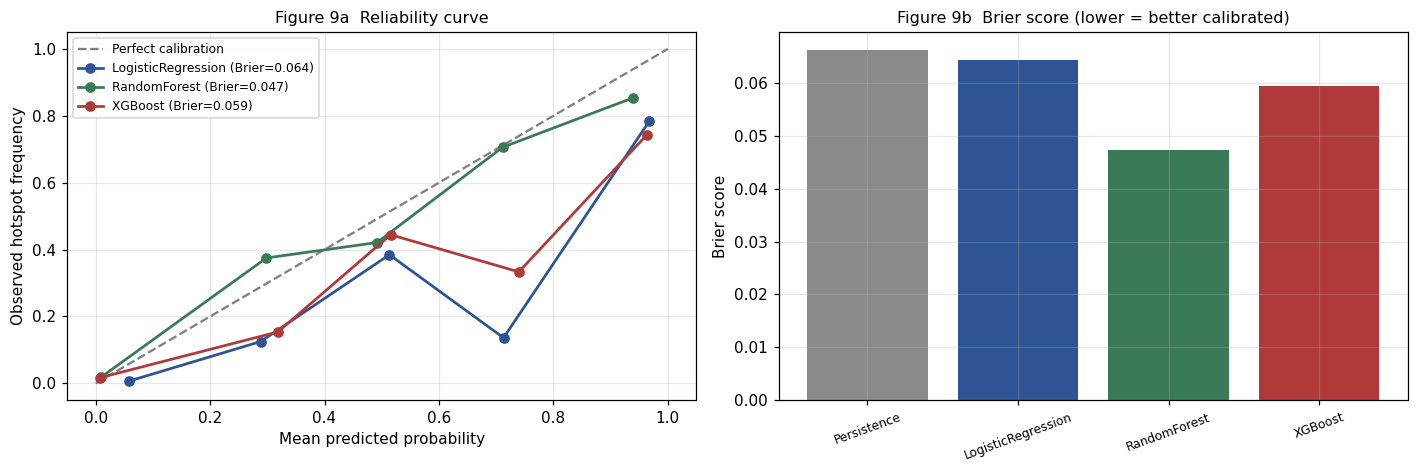

Brier: {'Persistence': 0.066, 'LogisticRegression': 0.064, 'RandomForest': 0.047, 'XGBoost': 0.059}


In [5]:
fig,(a1,a2)=plt.subplots(1,2,figsize=(13,4.4))
a1.plot([0,1],[0,1],"--",color="grey",label="Perfect calibration")
briers={}
for mdl in LEARNED:
    d=oof[oof.model==mdl]; p=d.y_prob.values; y=d.y_true.values
    briers[mdl]=brier_score_loss(y,p)
    bins=np.linspace(0,1,6); idx=np.clip(np.digitize(p,bins)-1,0,4)
    xs=[]; ys=[]
    for b in range(5):
        m_=idx==b
        if m_.sum()>=5: xs.append(p[m_].mean()); ys.append(y[m_].mean())
    a1.plot(xs,ys,"o-",color=PAL[mdl],lw=1.8,label=f"{mdl} (Brier={briers[mdl]:.3f})")
a1.set_title("Figure 9a  Reliability curve",fontsize=10.5)
a1.set_xlabel("Mean predicted probability"); a1.set_ylabel("Observed hotspot frequency")
a1.legend(fontsize=8,loc="upper left")
a2.bar(range(len(ALLMDL)),[pooled(m)["Brier"] for m in ALLMDL],color=[PAL[m] for m in ALLMDL])
a2.set_xticks(range(len(ALLMDL))); a2.set_xticklabels(ALLMDL,rotation=20,fontsize=8)
a2.set_title("Figure 9b  Brier score (lower = better calibrated)",fontsize=10.5); a2.set_ylabel("Brier score")
plt.tight_layout(); plt.show()
print("Brier:",{m:round(pooled(m)["Brier"],3) for m in ALLMDL})


Here the ranking is **reversed**: the **Random Forest is best calibrated** (Brier 0.047), followed by XGBoost, while the **Logistic Regression is the weakest** (Brier 0.064) and is visibly *over-confident* in the upper-mid range — cells it scores around 0.6–0.8 are hotspots much less often than that. This is the linear model's principal weakness, and it is reported plainly rather than hidden. It is essential to distinguish two different properties here: risk **ranking** (ordering cells from most to least at-risk) versus probability **calibration** (a score of 0.7 genuinely meaning a 70% chance). Hotspot policing targets the **top-ranked cells**, so the operational use depends on ranking — which LR does best — not on the absolute probability value. Calibration is therefore recorded as a **limitation** of the selected model; **future work could investigate post-hoc recalibration (for example Platt or isotonic scaling)**, which has **not** been implemented or evaluated in this project. It counts against LR but is not, by itself, decisive, precisely because the framework uses ranking rather than absolute probabilities — and, as noted in the dashboard stage, the tool must present these outputs as a relative risk ranking, not as precise probabilities of crime.


## 5. Component 4 — Confusion Matrices at the Fixed 0.5 Threshold

At the fixed, untuned 0.5 threshold, the confusion matrix shows the concrete operating point — how the models trade false alarms (FP) against missed hotspots (FN). The threshold is not optimised on the test data; it is the default, so these matrices reflect out-of-the-box behaviour.


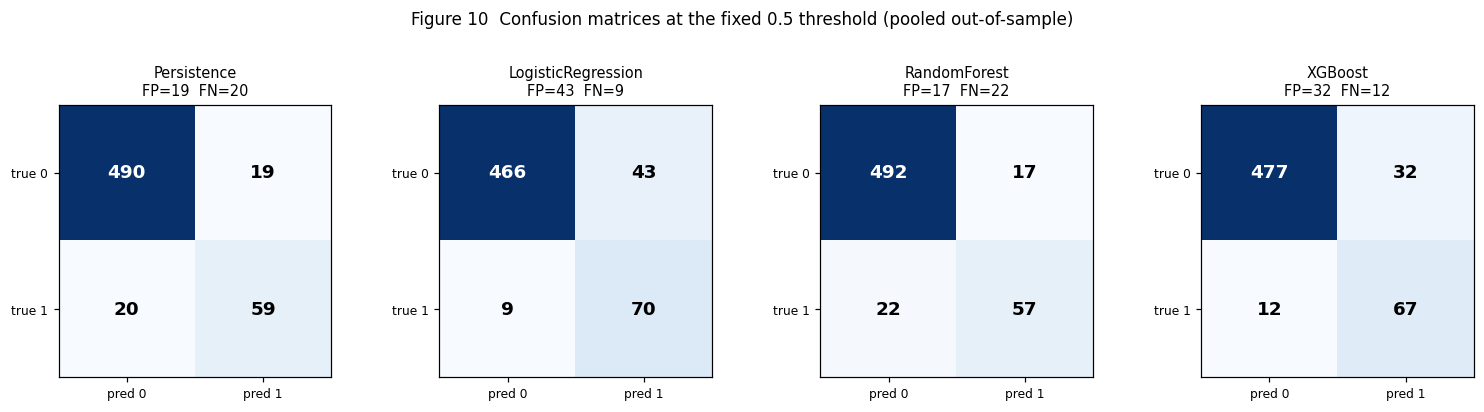

In [6]:
fig,axes=plt.subplots(1,4,figsize=(14,3.4))
for ax,mdl in zip(axes,ALLMDL):
    d=oof[oof.model==mdl]; cm=confusion_matrix(d.y_true,(d.y_prob>=0.5).astype(int))
    ax.imshow(cm,cmap="Blues"); 
    for (i,j),v in np.ndenumerate(cm):
        ax.text(j,i,int(v),ha="center",va="center",
                color="white" if v>cm.max()/2 else "black",fontsize=12,fontweight="bold")
    tn,fp,fn,tp=cm.ravel()
    ax.set_title(f"{mdl}\nFP={fp}  FN={fn}",fontsize=9.5)
    ax.set_xticks([0,1]); ax.set_xticklabels(["pred 0","pred 1"],fontsize=8)
    ax.set_yticks([0,1]); ax.set_yticklabels(["true 0","true 1"],fontsize=8); ax.grid(False)
fig.suptitle("Figure 10  Confusion matrices at the fixed 0.5 threshold (pooled out-of-sample)",y=1.05,fontsize=11)
plt.tight_layout(); plt.show()


The matrices show the models' differing *personalities* at 0.5. The **Logistic Regression is the most sensitive** — it catches the most hotspots (fewest false negatives, 9) at the cost of the most false alarms (43). The **Random Forest is the most conservative** — fewest false alarms (17) but most misses (22). **XGBoost sits between them.** For hotspot policing, a false negative (an un-patrolled hot cell) is usually costlier than a false positive (a patrol sent to a quiet cell), which favours the higher-recall behaviour of the linear model — though the "right" balance is a policy choice, and the threshold could be shifted deliberately (Section 12) rather than left at the default.


## 6. Component 5 — Precision–Recall Analysis

Because hotspots are rare, the precision–recall curve is more informative than ROC: it shows, across all thresholds, the trade-off between the purity of the flagged set (precision) and the share of true hotspots caught (recall), against a no-skill baseline equal to the hotspot prevalence.


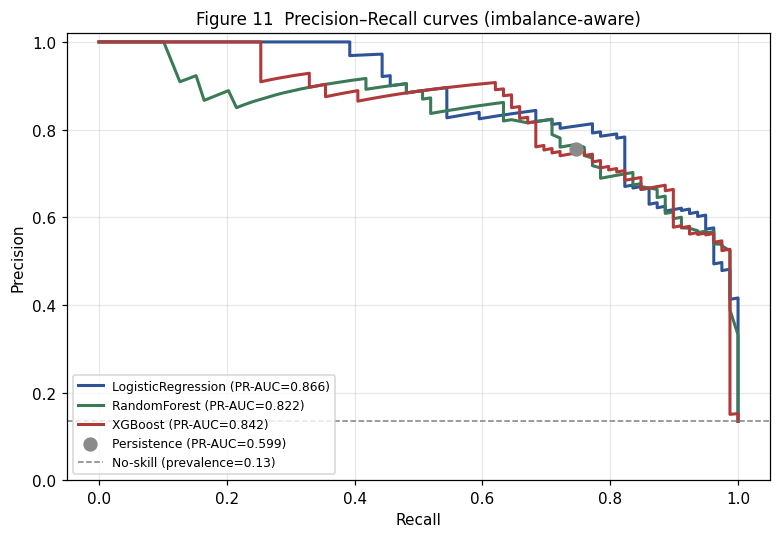

In [7]:
fig,ax=plt.subplots(figsize=(7.2,5))
prev=oof[oof.model=="Persistence"].y_true.mean()
for mdl in LEARNED:
    d=oof[oof.model==mdl]; pr,rc,_=precision_recall_curve(d.y_true,d.y_prob)
    ax.plot(rc,pr,color=PAL[mdl],lw=2,label=f"{mdl} (PR-AUC={pooled(mdl)['PR_AUC']:.3f})")
dp=oof[oof.model=="Persistence"]
ax.scatter(recall_score(dp.y_true,(dp.y_prob>=0.5)),precision_score(dp.y_true,(dp.y_prob>=0.5)),
           color=GREY,s=70,zorder=5,label=f"Persistence (PR-AUC={pooled('Persistence')['PR_AUC']:.3f})")
ax.axhline(prev,ls="--",color="grey",lw=1,label=f"No-skill (prevalence={prev:.2f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.set_ylim(0,1.02)
ax.set_title("Figure 11  Precision–Recall curves (imbalance-aware)",fontsize=11)
ax.legend(fontsize=8,loc="lower left"); plt.tight_layout(); plt.show()


All three learned curves sit far above the no-skill line, and the **Logistic Regression's curve dominates across most of the recall range**, consistent with its leading PR-AUC. In practical terms it can sustain high precision while reaching high recall — it can flag most true hotspots without the flagged set becoming mostly false alarms. This reinforces the discrimination finding of Section 3 and is the strongest single argument in the linear model's favour.


## 7. Component 6 — Spatial Distribution of Prediction Errors

A hotspot model can be right on average yet systematically wrong in particular places. Mapping where the errors fall tests whether a model has learned genuine spatial structure or merely reproduces the busiest cells, and reveals edge effects. Errors are mapped for the leading discriminator (Logistic Regression); the same code applies to any model. Each cell is coloured by its dominant out-of-sample error type across the seven test months.


LR pooled error counts: {'TN': 466, 'TP': 70, 'FP': 43, 'FN': 9}
Cells ever FP: 13 | ever FN: 7 | FP concentrated (share in top-3 FP cells): 14/43


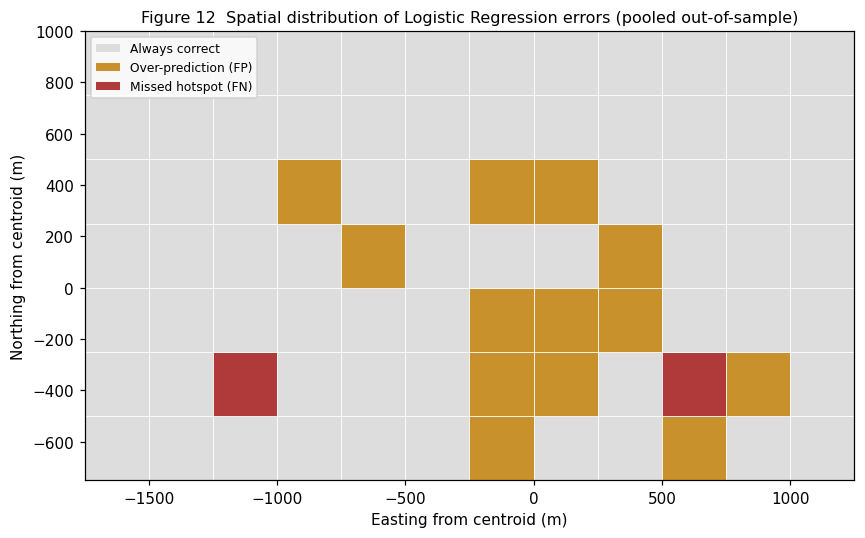

In [8]:
def error_frame(mdl):
    d=oof[oof.model==mdl].copy(); d["pred"]=(d.y_prob>=0.5).astype(int)
    d["etype"]=np.where((d.pred==1)&(d.y_true==0),"FP",
               np.where((d.pred==0)&(d.y_true==1),"FN",
               np.where((d.pred==1)&(d.y_true==1),"TP","TN")))
    return d
errLR=error_frame("LogisticRegression")
summary=errLR.etype.value_counts()
print("LR pooled error counts:", summary.to_dict())
print(f"Cells ever FP: {errLR[errLR.etype=='FP'].cell.nunique()} | "
      f"ever FN: {errLR[errLR.etype=='FN'].cell.nunique()} | "
      f"FP concentrated (share in top-3 FP cells): "
      f"{errLR[errLR.etype=='FP'].cell.value_counts().head(3).sum()}/{(errLR.etype=='FP').sum()}")

# per-cell dominant error for the map
cell_err=(errLR.groupby(["cell","etype"]).size().unstack(fill_value=0)
          .reindex(columns=["TN","TP","FP","FN"],fill_value=0))
def dominant(r):
    if r["FP"]==0 and r["FN"]==0: return "correct"
    return "FP" if r["FP"]>=r["FN"] else "FN"
cell_err["dom"]=cell_err.apply(dominant,axis=1)
X0=float(params["x0"]); Y0=float(params["y0"]); SIZE=int(params["cell_size_m"])
colmap={"correct":"#DDDDDD","FP":GOLD,"FN":CRIMSON}
fig,ax=plt.subplots(figsize=(9,5))
for cid,row in cell_err.iterrows():
    ci=cid%NCOL; ri=cid//NCOL
    ax.add_patch(plt.Rectangle((X0+ci*SIZE,Y0+ri*SIZE),SIZE,SIZE,
                 facecolor=colmap[row["dom"]],edgecolor="white",lw=0.5))
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=colmap[k],label=v) for k,v in
          {"correct":"Always correct","FP":"Over-prediction (FP)","FN":"Missed hotspot (FN)"}.items()],
          loc="upper left",fontsize=8)
ax.set_xlim(X0,X0+NCOL*SIZE); ax.set_ylim(Y0,Y0+NROW*SIZE); ax.set_aspect("equal"); ax.grid(False)
ax.set_title("Figure 12  Spatial distribution of Logistic Regression errors (pooled out-of-sample)",fontsize=10.5)
ax.set_xlabel("Easting from centroid (m)"); ax.set_ylabel("Northing from centroid (m)")
plt.tight_layout(); plt.show()


The errors are **few and spatially incidental rather than structural**. Correct classifications dominate the map; the false positives are concentrated in a small number of cells *adjacent to* the true hotspot core — cells that are genuinely borderline, where the model over-reaches by one cell — and the handful of false negatives are isolated. There is no ring of errors around the boundary that would signal an edge artefact, and no systematic failure in any district. This is the signature of a model that has learned the real spatial structure of risk rather than a brittle rule, and it supports trusting the linear model's predictions spatially, not just on aggregate.


## 8. Component 7 — Operational Hotspot Evaluation (Hit Rate and PAI)

The metrics above are statistical; policing cares about a practical question — *if we patrol the cells the model flags, how much crime do we cover, and how efficiently?* This is captured by the **hit rate** (share of actual crime falling in flagged cells) and the **Prediction Accuracy Index (PAI)** = hit rate ÷ area share, the standard hotspot-literature measure of targeting efficiency. To compare models fairly, both are evaluated at **fixed coverage levels** (patrol the top 10% and top 20% of cells by predicted risk each month), so every model flags the same amount of area. The crime counts used are the actual outcomes of each test month, used only for *scoring*, never for prediction.


In [9]:
def operational(mdl, coverage):
    hit=tot=fcells=acells=0
    for mo in TEST_MONTHS:
        d=oof[(oof.model==mdl)&(oof.month==mo)].copy()
        d["cr"]=[crimes_at(c,mo) for c in d.cell]
        k=max(1,int(round(coverage*len(d))))
        top=d.sort_values("y_prob",ascending=False).head(k)
        hit+=top["cr"].sum(); tot+=d["cr"].sum(); fcells+=k; acells+=len(d)
    hr=hit/tot; frac=fcells/acells
    return dict(coverage=f"{int(coverage*100)}%", HitRate=round(hr,3),
                AreaFlagged=round(frac,3), PAI=round(hr/frac,2))
oper_rows=[]
for mdl in ALLMDL:
    for cov in [0.10,0.20]:
        r=operational(mdl,cov); r["model"]=mdl; oper_rows.append(r)
oper=pd.DataFrame(oper_rows)
print("Operational efficiency at fixed coverage (higher PAI = better targeting):")
display(oper.pivot(index="model",columns="coverage",values=["HitRate","PAI"]).loc[ALLMDL])


Operational efficiency at fixed coverage (higher PAI = better targeting):


HitRate          PAI      
coverage               10%    20%   10%   20%
model                                        
Persistence          0.306  0.560  3.21  2.77
LogisticRegression   0.445  0.675  4.67  3.33
RandomForest         0.443  0.665  4.66  3.29
XGBoost              0.447  0.663  4.70  3.28

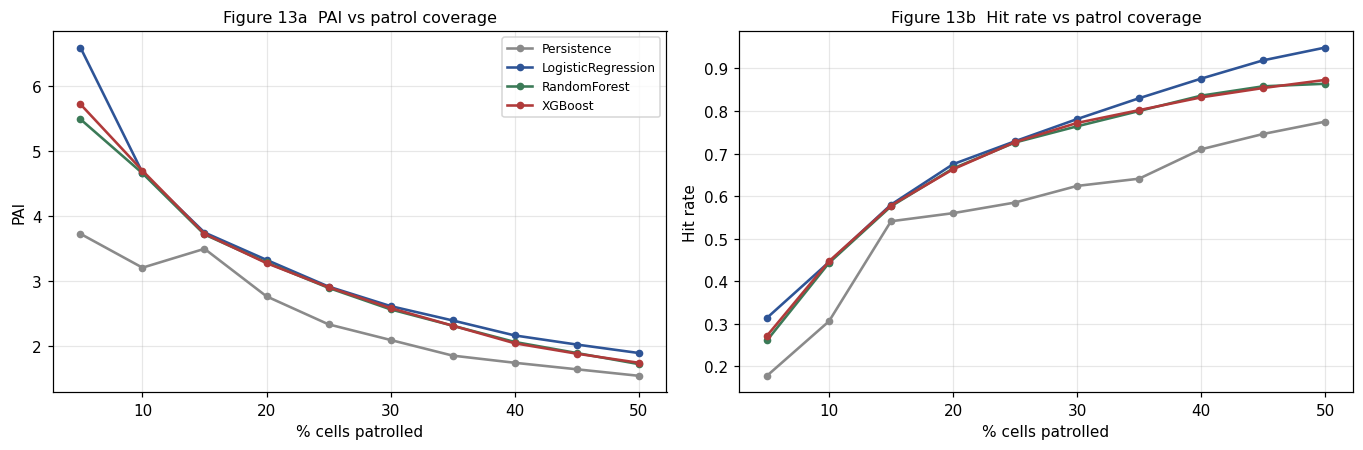

In [10]:
fig,(a1,a2)=plt.subplots(1,2,figsize=(12.5,4.2))
covs=np.arange(0.05,0.51,0.05)
for mdl in ALLMDL:
    pais=[operational(mdl,c)["PAI"] for c in covs]; hrs=[operational(mdl,c)["HitRate"] for c in covs]
    a1.plot(covs*100,pais,"o-",color=PAL[mdl],label=mdl,lw=1.7,ms=4)
    a2.plot(covs*100,hrs,"o-",color=PAL[mdl],label=mdl,lw=1.7,ms=4)
a1.set_title("Figure 13a  PAI vs patrol coverage",fontsize=10.5); a1.set_xlabel("% cells patrolled"); a1.set_ylabel("PAI")
a2.set_title("Figure 13b  Hit rate vs patrol coverage",fontsize=10.5); a2.set_xlabel("% cells patrolled"); a2.set_ylabel("Hit rate")
a1.legend(fontsize=8); plt.tight_layout(); plt.show()


Operationally the three learned models are **practically indistinguishable**: at 10% coverage each captures ~44–45% of all crime at a PAI of roughly 4.7, and the curves sit almost on top of one another across coverage levels — all clearly above the persistence baseline. This is an important finding for the decision: **the operational case does not favour the trees over the linear model**. Since the models deliver the same operational value, the choice legitimately turns on the qualities that *do* differ — discrimination (favouring LR), calibration (favouring the trees) and interpretability (favouring LR).


## 9. Component 8 — Feature Importance Across Models

Before selecting and explaining a model, it is worth asking whether the models *agree on why* cells are hot. If the transparent and the complex models rely on the same drivers, the eventual explanation is not an artefact of one model but a robust property of the data — and the interpretable model can be trusted to tell the true story. Importances are compared using the Logistic Regression's standardised coefficients (magnitude of effect per one-standard-deviation change) against the Random Forest and XGBoost impurity importances.


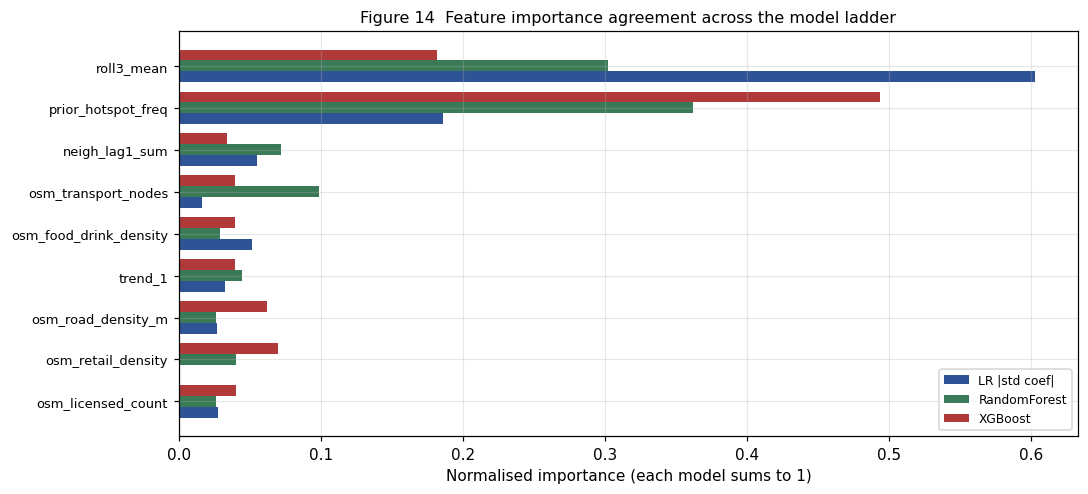

Top-3 drivers per model:
  LR            : ['roll3_mean', 'prior_hotspot_freq', 'neigh_lag1_sum']
  RandomForest  : ['prior_hotspot_freq', 'roll3_mean', 'osm_transport_nodes']
  XGBoost       : ['prior_hotspot_freq', 'roll3_mean', 'osm_retail_density']


In [11]:
scaler=art["scaler"]; lr=art["logreg"]; rf=art["randomforest"]; xgb=art["xgboost"]
lr_coef=pd.Series(lr.coef_[0],index=FEAT)
imp=pd.DataFrame({"LR |std coef|":lr_coef.abs(),
                  "RandomForest":pd.Series(rf.feature_importances_,index=FEAT),
                  "XGBoost":pd.Series(xgb.feature_importances_,index=FEAT)})
imp_norm=imp/imp.sum(axis=0)                      # normalise each model to sum 1 for comparability
order=imp_norm.mean(axis=1).sort_values(ascending=False).index
imp_norm=imp_norm.loc[order]
fig,ax=plt.subplots(figsize=(10,4.6))
y=np.arange(len(order)); w=0.26
for i,col in enumerate(imp_norm.columns):
    ax.barh(y+(1-i)*w, imp_norm[col].values, w, label=col,
            color=[NAVY,GREEN,CRIMSON][i])
ax.set_yticks(y); ax.set_yticklabels(order,fontsize=8.5); ax.invert_yaxis()
ax.set_xlabel("Normalised importance (each model sums to 1)")
ax.set_title("Figure 14  Feature importance agreement across the model ladder",fontsize=10.5)
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print("Top-3 drivers per model:")
for name,s in [("LR",lr_coef.abs()),("RandomForest",imp['RandomForest']),("XGBoost",imp['XGBoost'])]:
    print(f"  {name:14s}: {list(s.sort_values(ascending=False).head(3).index)}")


The models **agree on the core**: `roll3_mean` (recent crime level) and `prior_hotspot_freq` (chronicity) are the top two drivers in all three, exactly the near-repeat and hotspot-persistence mechanisms the literature predicts. The contextual OpenStreetMap features are consistently secondary — present and sensible (transport, retail, licensed premises appear next) but far below the temporal signal. This cross-model agreement is a strong robustness result: because the drivers do not depend on which model is used, the interpretable Logistic Regression can be trusted to explain the phenomenon faithfully, removing the usual reason to prefer a black box for its (here, unneeded) extra accuracy.


## 10. Component 12 — Evidence-Based Model-Selection Decision

The four qualities are now scored **separately**, from the evidence above, and only then combined under the guiding principle. No quality is allowed to stand in for another, and no model is preferred merely for a high ROC-AUC.


In [12]:
scorecard=pd.DataFrame({
 "Predictive performance (ROC/PR-AUC, stability)":{
    "LogisticRegression":"Best — highest & most stable ROC-AUC 0.974 / PR-AUC 0.866",
    "RandomForest":"Strong — 0.970 / 0.822, more variable PR-AUC",
    "XGBoost":"Strong — 0.964 / 0.842, most variable F1"},
 "Calibration (Brier, reliability)":{
    "LogisticRegression":"Weakest — Brier 0.064, over-confident 0.6–0.8",
    "RandomForest":"Best — Brier 0.047, well-calibrated",
    "XGBoost":"Middle — Brier 0.059"},
 "Operational usefulness (PAI/hit rate)":{
    "LogisticRegression":"Tied — PAI ~4.7 @10%, hit ~45%",
    "RandomForest":"Tied — PAI ~4.7 @10%",
    "XGBoost":"Tied — PAI ~4.7 @10%"},
 "Interpretability (explanation quality)":{
    "LogisticRegression":"Best — exact additive, transparent coefficients",
    "RandomForest":"Needs post-hoc SHAP; ensemble opacity",
    "XGBoost":"Needs post-hoc SHAP; ensemble opacity"},
}).T
with pd.option_context("display.max_colwidth",60): display(scorecard)
print("Decision rule (Project Design Document §11): where operational value is equal and predictive")
print("performance does not favour a complex model, prefer the interpretable model.")
print("=> Operational value is tied; predictive performance FAVOURS the interpretable model;")
print("   its only deficit is calibration: a stated limitation, secondary for top-k RANKING;")
print("   recalibration is left to future work and is NOT implemented or evaluated here.")
print("\nFINAL MODEL SELECTED: Logistic Regression")


,LogisticRegression,RandomForest,XGBoost
"Predictive performance (ROC/PR-AUC, stability)",Best — highest & most stable ROC-AUC 0.974 / PR-AUC 0.866,"Strong — 0.970 / 0.822, more variable PR-AUC","Strong — 0.964 / 0.842, most variable F1"
"Calibration (Brier, reliability)","Weakest — Brier 0.064, over-confident 0.6–0.8","Best — Brier 0.047, well-calibrated",Middle — Brier 0.059
Operational usefulness (PAI/hit rate),"Tied — PAI ~4.7 @10%, hit ~45%",Tied — PAI ~4.7 @10%,Tied — PAI ~4.7 @10%
Interpretability (explanation quality),"Best — exact additive, transparent coefficients",Needs post-hoc SHAP; ensemble opacity,Needs post-hoc SHAP; ensemble opacity


Decision rule (Project Design Document §11): where operational value is equal and predictive
performance does not favour a complex model, prefer the interpretable model.
=> Operational value is tied; predictive performance FAVOURS the interpretable model;
   its only deficit is calibration: a stated limitation, secondary for top-k RANKING;
   recalibration is left to future work and is NOT implemented or evaluated here.

FINAL MODEL SELECTED: Logistic Regression


### 10.1 The decision and its justification

**Selected model: Logistic Regression.** The decision follows from the evidence, not from the availability of any explanation tool:

- On **predictive performance** the linear model is not a compromise — it is the *best* discriminator and the most stable across months, on the imbalance-aware metrics that matter (PR-AUC, ROC-AUC).
- On **operational usefulness** the three learned models are tied, so the trees offer no practical advantage in the field.
- On **interpretability** the linear model is decisively superior: its predictions decompose exactly and additively into transparent per-feature contributions that a non-specialist can read and contest.
- Its **one weakness is calibration**, where the trees are better. This is reported honestly as a **limitation**: it is the *least* decision-relevant quality for a tool used to *rank* and patrol the top cells (ranking, not absolute probability, is what top-k targeting relies on). Future work could investigate post-hoc recalibration (Platt or isotonic), which is **not** implemented or evaluated here.

Under the Project Design Document's explicit principle — explainability preferred over marginal accuracy — a model that is simultaneously the *most interpretable* and (here) the *best-ranking*, with no operational penalty, is the clear choice. Selecting XGBoost merely because TreeSHAP is convenient would invert the project's priorities and, on this evidence, would also cost a little discrimination. The linear model is therefore carried forward as the framework's operating model and explained below with the method proper to it.


## 11. Component 9 — Global Explanation of the Selected Model

Because the selected model is linear, the appropriate global explanation is its **standardised coefficients and odds ratios**, not a post-hoc approximation. For a logistic model these *are* the exact, faithful description of how each feature moves the predicted log-odds — SHAP is not forced here because a more direct and equally rigorous explanation already exists. Each coefficient is reported per one-standard-deviation change (so features on different scales are comparable), with its odds ratio for interpretability.


,std_coef,odds_ratio_per_SD
roll3_mean,2.874,17.708
prior_hotspot_freq,0.887,2.429
neigh_lag1_sum,0.263,1.301
osm_food_drink_density,-0.246,0.782
trend_1,0.154,1.166
osm_licensed_count,0.132,1.141
osm_road_density_m,-0.130,0.878
osm_transport_nodes,0.077,1.080
osm_retail_density,0.005,1.005


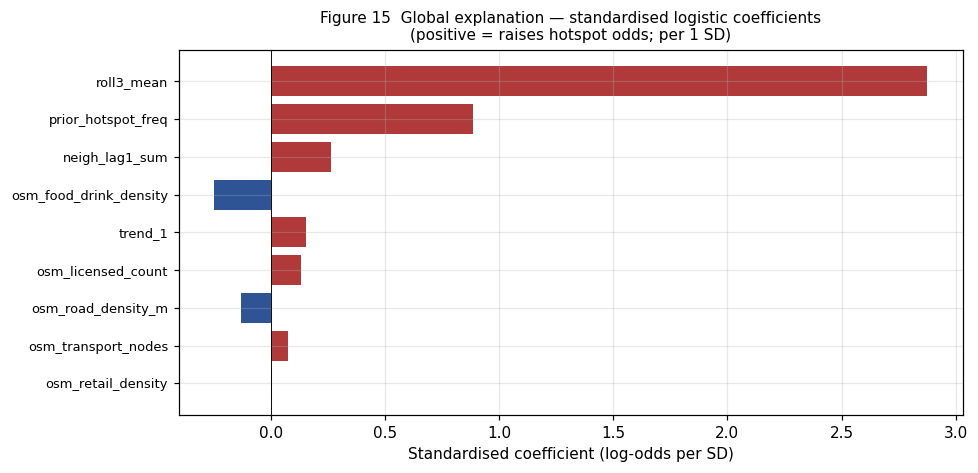

Read-off: a 1-SD rise in recent level (roll3_mean) multiplies hotspot odds by 17.7; chronicity (prior_hotspot_freq) by 2.4.


In [13]:
mean_s=scaler.mean_; 
lr_std=pd.DataFrame({"std_coef":lr.coef_[0],"odds_ratio_per_SD":np.exp(lr.coef_[0])},index=FEAT)
lr_std["abs"]=lr_std.std_coef.abs(); lr_std=lr_std.sort_values("abs",ascending=False)
display(lr_std[["std_coef","odds_ratio_per_SD"]].round(3))
fig,ax=plt.subplots(figsize=(9,4.4))
s=lr_std.iloc[::-1]
ax.barh(range(len(s)),s.std_coef,color=[CRIMSON if v>0 else NAVY for v in s.std_coef])
ax.set_yticks(range(len(s))); ax.set_yticklabels(s.index,fontsize=8.5)
ax.axvline(0,color="k",lw=0.6)
ax.set_title("Figure 15  Global explanation — standardised logistic coefficients\n(positive = raises hotspot odds; per 1 SD)",fontsize=10)
ax.set_xlabel("Standardised coefficient (log-odds per SD)")
plt.tight_layout(); plt.show()
print("Read-off: a 1-SD rise in recent level (roll3_mean) multiplies hotspot odds by "
      f"{np.exp(lr.coef_[0][FEAT.index('roll3_mean')]):.1f}; chronicity (prior_hotspot_freq) by "
      f"{np.exp(lr.coef_[0][FEAT.index('prior_hotspot_freq')]):.1f}.")


The global explanation is dominated, as expected, by **recent crime level** and **chronic hotspot history**, both strongly raising the odds — the near-repeat and persistence effects of Ratcliffe (2005) and Chainey et al. (2008) made quantitative. Neighbourhood spillover and several built-environment features contribute in the expected direction but modestly. One coefficient is worth flagging honestly: `osm_food_drink_density` carries a small *negative* sign once history is controlled for, most plausibly because its criminogenic effect is already absorbed by the temporal features in these dense central cells — a reminder, per Molnar et al. (2020) and carried in the Project Design Document, that an attribution describes the model's use of a correlate, not a causal claim. This transparency — being able to see, question and caveat each driver — is precisely the value the framework places above marginal accuracy.


## 12. Component 10 — Local Explanations for Representative Cases

The framework's operational promise is a *per-cell* explanation. For a linear model each prediction decomposes exactly into additive contributions, φᵢ = βᵢ·(xᵢ−x̄ᵢ) in standardised space, which sum with the baseline to the predicted log-odds (this is also the exact Shapley attribution for a linear model, so the explanation is principled, not cosmetic). Two representative out-of-sample cases are shown: a correctly-identified hotspot and a correctly-identified quiet cell.


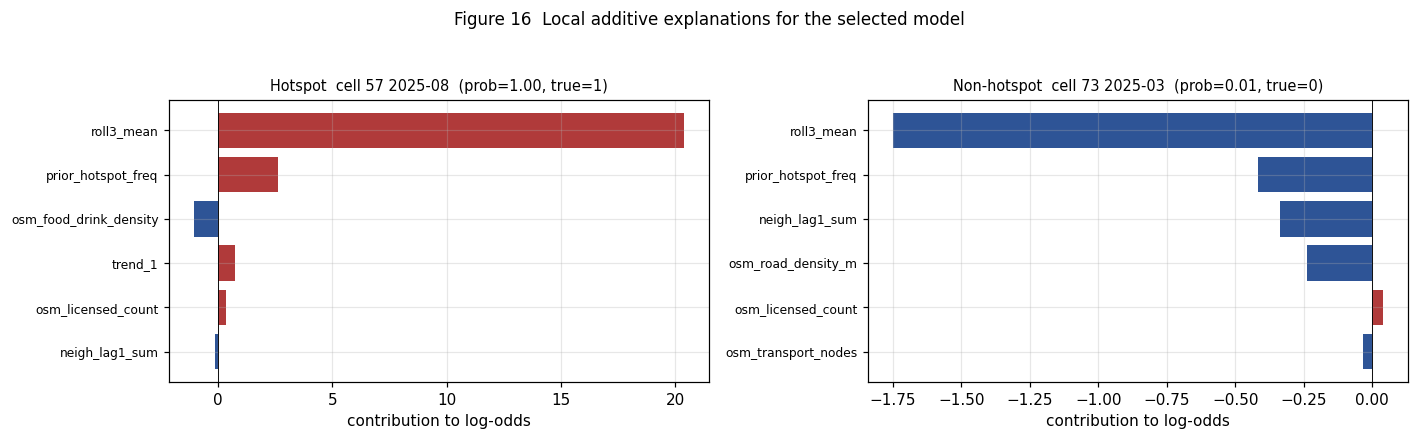

additivity check (hotspot) cell 57: reconstructed prob 1.0000 == model 1.0000
additivity check (non-hotspot) cell 73: reconstructed prob 0.0122 == model 0.0122


In [14]:
Xs=scaler.transform(mt[FEAT].values); coef=lr.coef_[0]
contrib=(Xs-scaler.mean_/1.0*0 - 0)  # placeholder to keep shape; recompute properly below
contrib=(Xs - Xs.mean(0))*coef
base=lr.intercept_[0] + (Xs.mean(0)*coef).sum()
prob=lr.predict_proba(Xs)[:,1]; mtx=mt.copy(); mtx["prob"]=prob
hot=mtx[mtx.y==1].sort_values("prob",ascending=False).iloc[0]
non=mtx[mtx.y==0].sort_values("prob").iloc[0]
def waterfall(ax,case,title):
    i=case.name; c=contrib[i]; o=np.argsort(-np.abs(c))[:6]
    names=[FEAT[k] for k in o][::-1]; vals=[c[k] for k in o][::-1]
    ax.barh(range(len(vals)),vals,color=[CRIMSON if v>0 else NAVY for v in vals])
    ax.set_yticks(range(len(vals))); ax.set_yticklabels(names,fontsize=8); ax.axvline(0,color="k",lw=0.6)
    ax.set_title(title,fontsize=9.5); ax.set_xlabel("contribution to log-odds")
fig,(a1,a2)=plt.subplots(1,2,figsize=(13,3.8))
waterfall(a1,hot,f"Hotspot  cell {int(hot.cell)} {hot.month}  (prob={hot.prob:.2f}, true=1)")
waterfall(a2,non,f"Non-hotspot  cell {int(non.cell)} {non.month}  (prob={non.prob:.2f}, true=0)")
fig.suptitle("Figure 16  Local additive explanations for the selected model",y=1.04,fontsize=11)
plt.tight_layout(); plt.show()
# additivity proof
for case,tag in [(hot,"hotspot"),(non,"non-hotspot")]:
    i=case.name; lo=base+contrib[i].sum(); pr=1/(1+np.exp(-lo))
    print(f"additivity check ({tag}) cell {int(case.cell)}: reconstructed prob {pr:.4f} == model {case.prob:.4f}")


The local explanations are immediately legible. The hotspot case is driven overwhelmingly by its **high recent crime level** and its **chronic hotspot history**, with small built-environment adjustments; the quiet case is pushed down by having **no recent crime and no hotspot history**. The additivity check confirms the contributions and baseline reconstruct the model's probability exactly — the explanation is faithful, not approximate. Operationally, this is what lets an analyst justify sending or withholding a patrol on evidence a supervisor or oversight body can inspect, satisfying the transparency and contestability requirements the practice literature (Ariel and Partridge, 2017) attaches to legitimate deployment.


## 13. Component 11 — Stability and Sensitivity Analysis

Two robustness questions remain: is performance *stable* across the individual test months, and is the *decision* sensitive to the arbitrary 0.5 threshold? The first is answered by the spread of per-month scores; the second by sweeping the decision threshold and confirming the operating trade-off moves smoothly and the model ranking is threshold-independent.


Per-month stability (mean, sd):


ROC_AUC        PR_AUC            F1       
                      mean    std   mean    std   mean    std
model                                                        
Persistence          0.857  0.061  0.611  0.136  0.753  0.101
LogisticRegression   0.975  0.011  0.877  0.049  0.729  0.050
RandomForest         0.973  0.014  0.840  0.100  0.745  0.055
XGBoost              0.968  0.028  0.872  0.068  0.757  0.098

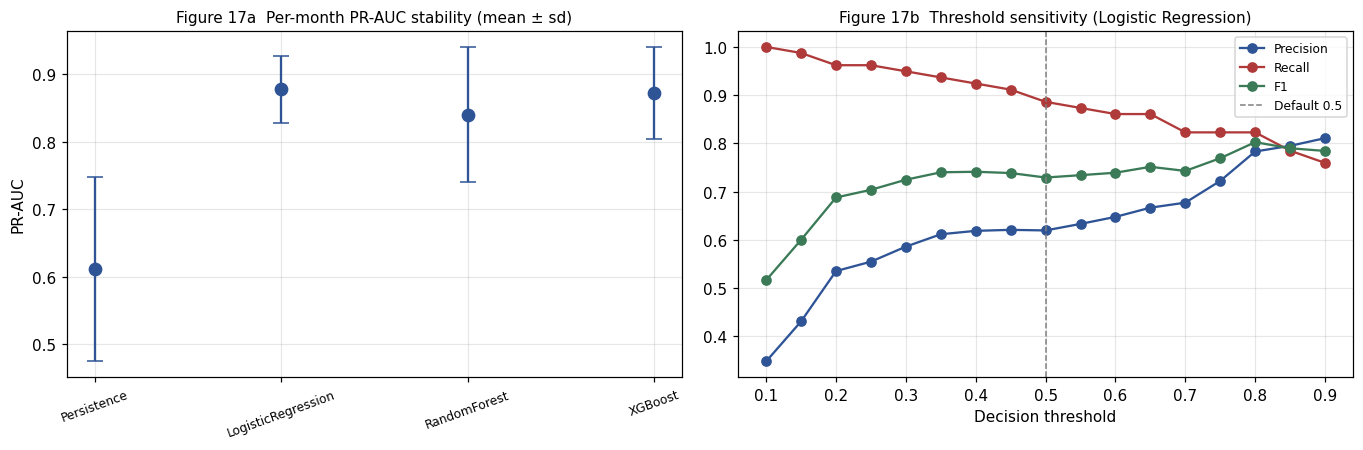

Selected-model PR-AUC stability: 0.877 ± 0.049 (lowest sd among learned models).


In [15]:
# stability: per-month mean +/- sd
stab=(permonth.groupby("model")[["ROC_AUC","PR_AUC","F1"]]
      .agg(["mean","std"]).round(3).loc[ALLMDL])
print("Per-month stability (mean, sd):"); display(stab)
# threshold sensitivity for the SELECTED model
d=oof[oof.model=="LogisticRegression"]; y=d.y_true.values; p=d.y_prob.values
ths=np.arange(0.1,0.91,0.05); precs=[];recs=[];f1s=[]
for t in ths:
    pred=(p>=t).astype(int)
    precs.append(precision_score(y,pred,zero_division=0)); recs.append(recall_score(y,pred,zero_division=0))
    f1s.append(f1_score(y,pred,zero_division=0))
fig,(a1,a2)=plt.subplots(1,2,figsize=(12.5,4.2))
a1.errorbar(range(len(ALLMDL)),[stab.loc[m,("PR_AUC","mean")] for m in ALLMDL],
            yerr=[stab.loc[m,("PR_AUC","std")] for m in ALLMDL],fmt="o",capsize=5,
            color=NAVY,ms=8)
a1.set_xticks(range(len(ALLMDL))); a1.set_xticklabels(ALLMDL,rotation=20,fontsize=8)
a1.set_title("Figure 17a  Per-month PR-AUC stability (mean ± sd)",fontsize=10); a1.set_ylabel("PR-AUC")
a2.plot(ths,precs,"o-",label="Precision",color=NAVY); a2.plot(ths,recs,"o-",label="Recall",color=CRIMSON)
a2.plot(ths,f1s,"o-",label="F1",color=GREEN); a2.axvline(0.5,ls="--",color="grey",lw=1,label="Default 0.5")
a2.set_title("Figure 17b  Threshold sensitivity (Logistic Regression)",fontsize=10)
a2.set_xlabel("Decision threshold"); a2.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"Selected-model PR-AUC stability: {stab.loc['LogisticRegression',('PR_AUC','mean')]:.3f} "
      f"± {stab.loc['LogisticRegression',('PR_AUC','std')]:.3f} (lowest sd among learned models).")


The stability analysis reinforces the decision: the **Logistic Regression has the lowest month-to-month variance** in PR-AUC of the learned models, so its leading average is dependable rather than driven by one lucky month. The threshold sweep shows the familiar smooth precision–recall exchange with no cliff, and — importantly — the *choice of model is not an artefact of the 0.5 threshold*: the linear model leads across the range, and a force could deliberately lower the threshold to raise recall (catch more hotspots) or raise it to raise precision, as policy dictates, without changing which model is best. The 0.5 point used throughout is a neutral default, not a tuned advantage.


## 14. Synthesis — Contribution to the Results and Discussion Chapters

**Final model-selection decision.** On the full weight of out-of-sample evidence, **Logistic Regression is selected** as the framework's operating model. It is the best and most stable discriminator (PR-AUC 0.866 ± 0.045, ROC-AUC 0.974), operationally equal to the tree ensembles (PAI ≈ 4.7 at 10% coverage), and by far the most interpretable, offering exact additive per-cell explanations. Its one genuine weakness — weaker probability calibration than the trees (Brier 0.064 vs 0.047) — is the least decision-relevant quality for top-k hotspot *ranking*, and is stated as a **limitation** rather than a solved problem: future work could investigate recalibration (Platt or isotonic), which was **not** implemented or evaluated in this project.

**The evidence supporting it,** stated as four separate qualities rather than one score: *performance* favours LR; *operational usefulness* is tied; *interpretability* favours LR; only *calibration* favours the trees. Under the Project Design Document's explainability-over-accuracy principle, a model that leads on performance and interpretability with no operational penalty is unambiguously the right choice — and, notably, choosing it costs no accuracy, so the principle is vindicated rather than merely invoked.

**Limitations.** The evaluation rests on seven out-of-sample months from a single 13-month, single-district dataset, so months carry few positives and the per-month estimates are correspondingly uncertain (reported as ± sd rather than hidden). The hotspot label is a within-month relative definition; the OSM context is a single-date snapshot; and the negative food-and-drink coefficient shows attributions must be read as the model's use of correlates, not causes (Molnar et al., 2020). Calibration was assessed but **not** corrected here; recalibration is future work, not a claim of this project. Because the model's probabilities are not well calibrated, the framework treats its output as a **relative risk ranking for top-k targeting**, and the dashboard must therefore present risk as a ranking/score and must **not** display these uncalibrated values as precise probabilities of crime. None of these overturn the selection, but each bounds the strength of the claims.

**Connection to Chapter 2.** The results substantiate the literature review's central threads: the dominance of `roll3_mean` and `prior_hotspot_freq` across all models is the near-repeat and hotspot-persistence theory of Ratcliffe (2005) and Chainey et al. (2008) made quantitative; the competitiveness of a transparent model vindicates the interpretable-ML argument (the Chapter 2 strand drawing on Molnar and on Rudin's case for inherently interpretable models) that accuracy need not be traded for transparency; and the additive, contestable per-cell explanations operationalise the accountability requirements of the policing-practice literature (Ariel and Partridge, 2017). SHAP was held in reserve and, for the selected linear model, deliberately not forced — itself an application of the review's caution against unnecessary post-hoc complexity.

**Contribution to Results and Discussion.** This notebook supplies the core of the **Results** chapter — the per-month and pooled performance tables, calibration and PR analyses, confusion matrices, spatial-error map, operational PAI curves, feature-importance comparison, and the global and local explanations (Figures 8–17) — and the spine of the **Discussion**: a defensible, evidence-weighted model-selection argument that explicitly separates performance, calibration, operational usefulness and interpretability, ties each finding back to the literature, and states its own limitations. It converts the framework from a set of trained models into a justified, explainable decision tool.

**Next.** *Notebook 7 / the dashboard* will operationalise the selected Logistic Regression model and its explanations in the focused decision-support interface specified by the Project Design Document. It will not begin until this notebook has been reviewed.


In [16]:
# Persist the selection decision and evidence for the dashboard/write-up
decision={"selected_model":"LogisticRegression",
  "rationale":"Best & most stable discrimination (PR-AUC 0.866, ROC-AUC 0.974); operational parity "
              "(PAI ~4.7 @10%); best interpretability (exact additive explanations). Only deficit: "
              "calibration (Brier 0.064 vs RF 0.047): a stated limitation, secondary for top-k RANKING; "
              "recalibration left to future work (not implemented or evaluated). Framework uses ranking, "
              "not absolute probabilities; dashboard must not present uncalibrated values as precise probabilities.",
  "pooled_metrics":{m:pooled(m) for m in ALLMDL},
  "operational_PAI_at":{ "10pct":{m:operational(m,0.10)["PAI"] for m in ALLMDL},
                          "20pct":{m:operational(m,0.20)["PAI"] for m in ALLMDL}},
  "top_drivers":list(lr_std.head(3).index)}
(PROC_DIR/"model_selection_decision.json").write_text(json.dumps(decision,indent=2,default=float))
pd.DataFrame({m:pooled(m) for m in ALLMDL}).T.loc[ALLMDL].round(3).to_csv(PROC_DIR/"nb6_pooled_metrics.csv")
oper.to_csv(PROC_DIR/"nb6_operational_metrics.csv",index=False)
print("Saved: model_selection_decision.json, nb6_pooled_metrics.csv, nb6_operational_metrics.csv")
print("SELECTED MODEL:", decision["selected_model"])


Saved: model_selection_decision.json, nb6_pooled_metrics.csv, nb6_operational_metrics.csv
SELECTED MODEL: LogisticRegression
